# Heart Disease Prediction: A Machine Learning Approach #

**Author: Shashank Yadav Kalki**

**Student ID: 124113611**

## 1. Introduction ##

In this notebook, I have developed multiple machine learning models to predict heart disease using data from the IEEE DataPort database and compared all of the models using performance metrics to come up with the best performing model that predicts the probability of a person having a heart disease with the best performance.
The dataset that i have used for this assignment contains 1190 records with 11 features and a target variable indicating the presence or absence of heart disease.
The dataset I have used is "heart_disease_data.csv from the IEEE DataPort database.





## 2. Data Exploration and Analysis ##



### Libraries Chosen: ###
  I have chosen the following libraries for the following reasons:
- **pandas**: Essential for data manipulation and analysis in Python
- **numpy**: Provides support for large, multi-dimensional arrays and mathematical functions
- **matplotlib** and **seaborn**: Visualization libraries that help understand data distributions and relationships

In [1]:
# Import necessary libraries for data analysis and visualization
import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical operations and handling arrays
import matplotlib.pyplot as plt  # For creating static visualizations
import seaborn as sns  # For statistical visualizations


# Setting the style for our visualizations
plt.style.use('fivethirtyeight')
sns.set(style='whitegrid')

# For displaying all columns in the dataframe
pd.set_option('display.max_columns', None)

# Loading the "Heart_disease.csv" dataset
df = pd.read_csv('heart_disease_data.csv')

# Displaying basic information to inspect the dataset's size
print("Initial dataset shape:", df.shape)


Initial dataset shape: (1190, 12)


# 3. Data Preprocessing #

## Missing Values and Dupliates Analysis ##
Once i explore the dataset, i believe the next step is to enhance or refine the data we have at hand. Here, I checked for missing values and duplicates that could skew our analysis.

Identifying such issues in the inital phase of Data Exploratory Analysis, allows us to develop an appropriate strategy for handling them. Duplicate rows can lead to bias in model training, especially if they end up in both training and testing sets.

Fortunately, there were no missing values.Thus, no imputation methods were used in this dataset.

For duplicates, I removed them while keeping the first occurrence (`keep='first'`). Removing duplicates prevents the model from giving undue weight to repeated patterns.

In [2]:

# Check for missing values in the dataset
missing_values = df.isnull().sum()
print("\nChecking for missing values in each column:")
print(missing_values)

# Determine if there are any missing values in the dataset
total_missing = missing_values.sum()
if total_missing == 0:
    print("\nThe dataset does not contain any missing values.")
    print("No imputation methods were needed for this dataset.")
else:
    print(f"\nThe dataset contains {total_missing} missing values.")

# Check for duplicate rows
duplicates = df.duplicated().sum()  # Count number of duplicate rows

# Remove duplicate rows if any exist
if duplicates > 0:
    original_shape = df.shape  # Store the original shape before removing duplicates
    df = df.drop_duplicates(keep='first')  # Remove duplicate rows, keeping the first occurrence
    new_shape = df.shape  # Store the new shape after removing duplicates

    print(f"✅ Removed {duplicates} duplicate rows.")
    print(f"📊 Dataset shape changed from {original_shape} to {new_shape}.")
    reduction_percentage = (duplicates / original_shape[0]) * 100
    print(f"📉 This represents a {reduction_percentage:.2f}% reduction in dataset size.")
else:
  print("No Duplicate Rows Found")# If no duplicate rows found

# Verify data cleaning results
print("\nData cleaning summary:")
print(f"- Final dataset shape: {df.shape}")
print(f"- Missing values: {df.isnull().sum().sum()}")
print(f"- Duplicate rows remaining: {df.duplicated().sum()}")
print("\nThe dataset is now ready for exploratory data analysis and modeling.")


Checking for missing values in each column:
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

The dataset does not contain any missing values.
No imputation methods were needed for this dataset.
✅ Removed 272 duplicate rows.
📊 Dataset shape changed from (1190, 12) to (918, 12).
📉 This represents a 22.86% reduction in dataset size.

Data cleaning summary:
- Final dataset shape: (918, 12)
- Missing values: 0
- Duplicate rows remaining: 0

The dataset is now ready for exploratory data analysis and modeling.


## Target Variable Distribution ##

Understanding the distribution of our target variable (heart disease) is important because:

1. It tells us whether the dataset is balanced or imbalanced.
2. An imbalanced dataset might require special handling techniques like resampling.
3. It helps us interpret model performance metrics correctly

The bar chart visually represents this distribution, while the percentage calculations give us a precise understanding of the class balance.

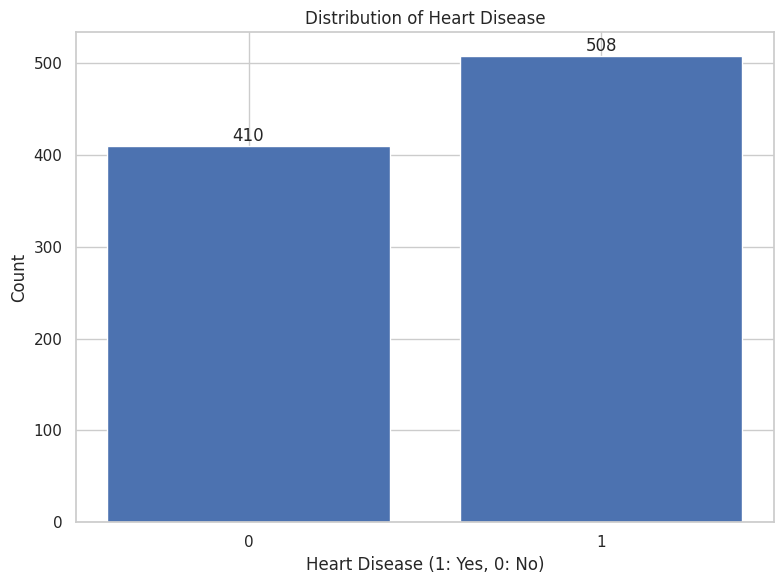

Percentage of patients with heart disease: 55.34%
Percentage of patients without heart disease: 44.66%


In [3]:
# Explore the distribution of the target variable
plt.figure(figsize=(8, 6))
target_counts = df['target'].value_counts()
plt.bar(target_counts.index, target_counts.values)
plt.title('Distribution of Heart Disease')#Title of the bar chart
plt.xlabel('Heart Disease (1: Yes, 0: No)')# X axis label
plt.ylabel('Count')# Y axis Label
plt.xticks([0, 1])
for i, v in enumerate(target_counts.values):
    plt.text(target_counts.index[i], v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()
#Displays the percentage of patients with and without heart disease from the data
print(f"Percentage of patients with heart disease: {target_counts[1] / len(df) * 100:.2f}%")
print(f"Percentage of patients without heart disease: {target_counts[0] / len(df) * 100:.2f}%")


## Numerical Feature Distribution ##

Examining the distribution of numerical features helps us:

1. Identifying potential outliers that might affect model performance
2. Understand whether features follow normal distributions
3. Determine if scaling or normalization might be beneficial

I've created a custom function to generate histograms with kernel density estimates (KDE) for each numerical feature. The KDE curve helps visualize the underlying distribution shape. I've selected key numerical features like age, blood pressure, cholesterol, heart rate, and oldpeak (ST depression) which are clinically relevant to heart disease diagnosis.

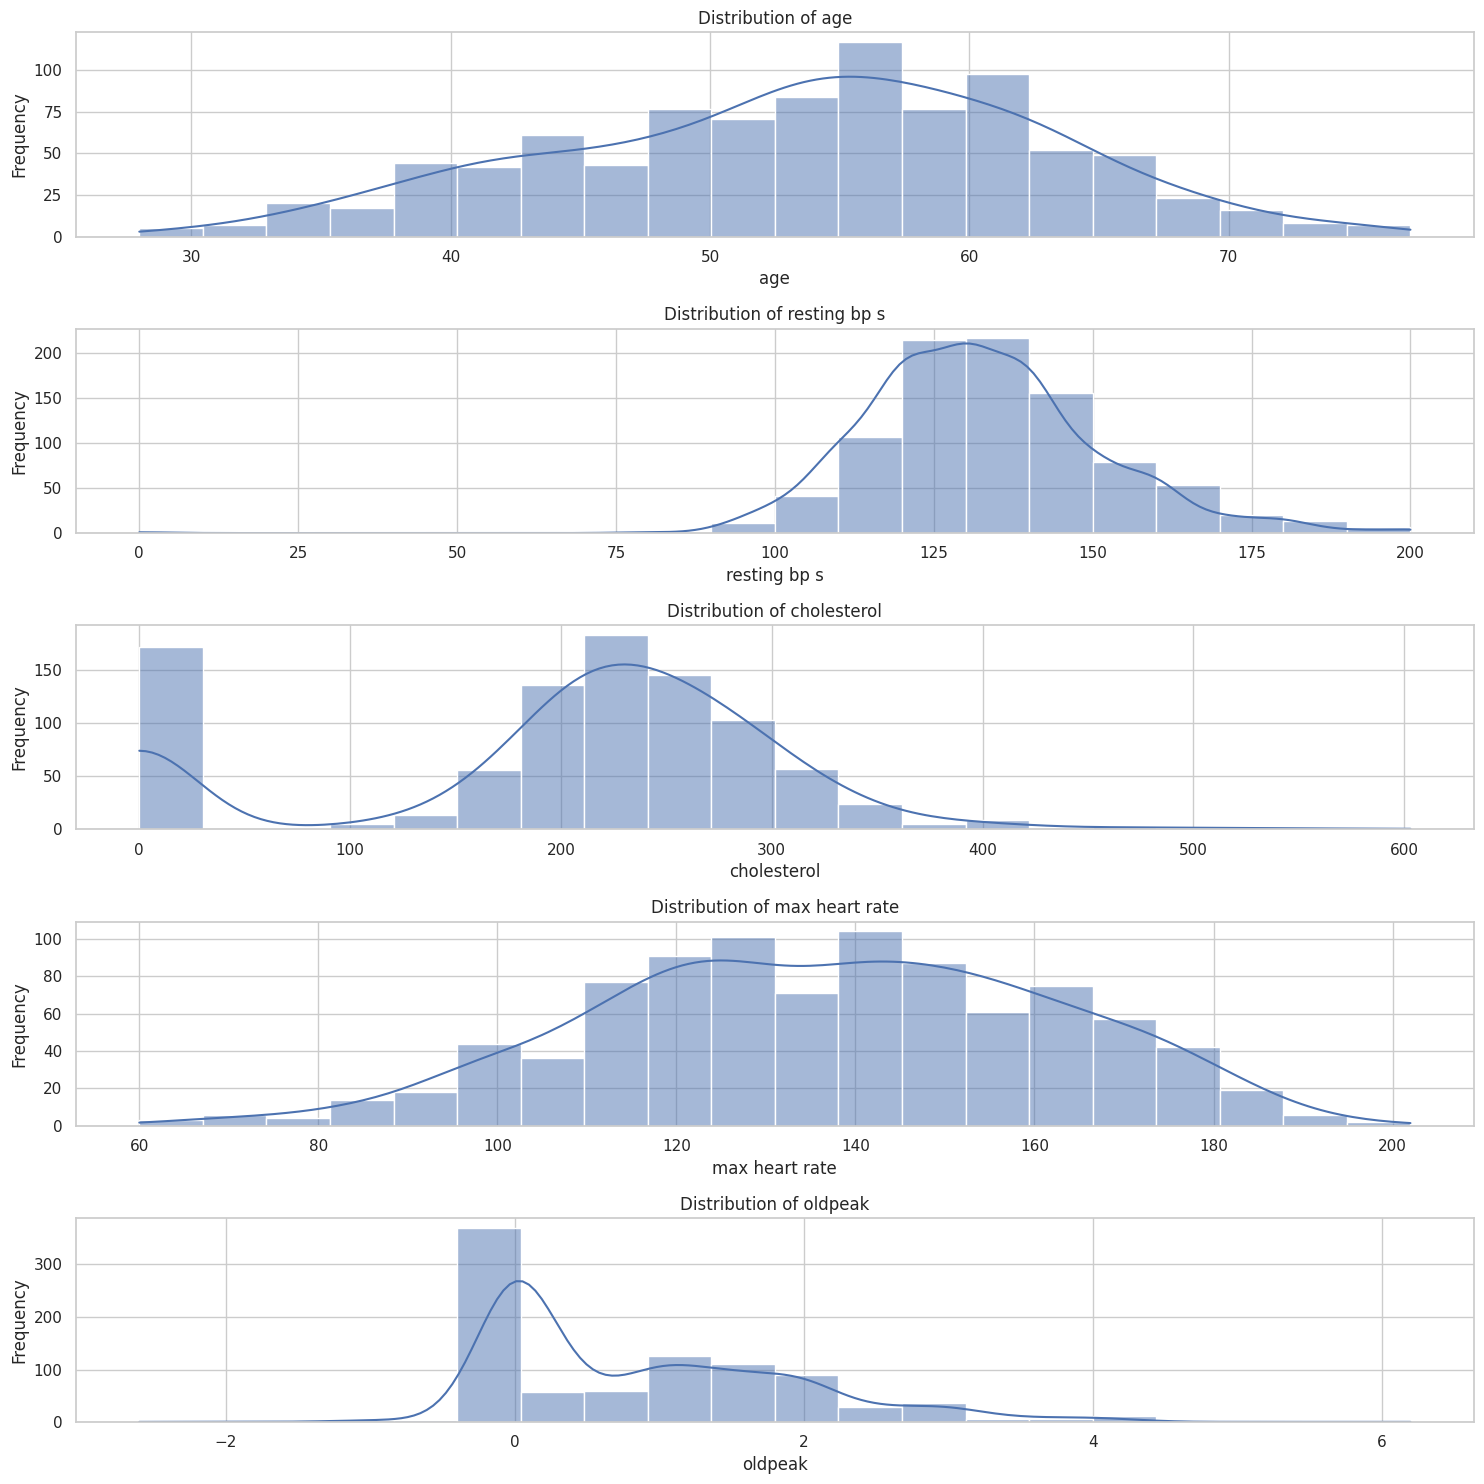

In [4]:
# Function to create histograms for numerical features
def plot_histograms(dataframe, numerical_cols, bins=20, figsize=(15, 15)):
    """
    Create histograms for each numerical feature in the dataframe

    Parameters:
    - dataframe: pandas DataFrame containing the data
    - numerical_cols: list of column names to create histograms for
    - bins: number of bins for the histograms
    - figsize: size of the figure
    """
    fig, axes = plt.subplots(len(numerical_cols), 1, figsize=figsize)

    for i, col in enumerate(numerical_cols):
        sns.histplot(data=dataframe, x=col, kde=True, ax=axes[i], bins=bins)# KDE = "True" means that i have used kernel densite estimation to visualise the distribution
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

# Select numerical features for histograms
numerical_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

# Create histograms for numerical features
plot_histograms(df, numerical_features)

## Categorical feature distributions ##
Categorical features in medical datasets often represent different conditions, symptoms, or test results that can be vital for diagnosis.

For our heart disease dataset, categorical variables like chest pain type, exercise-induced angina, and ST slope can be strong indicators of heart conditions. Visualizing the distribution of these categorical features helps us:

1. To Understand the prevalence of different conditions in our dataset
2. To Identify any heavily imbalanced categories that might need special handling
3. Begin to see patterns that might correlate with heart disease

I'm using bar plots with value labels to clearly show the count for each category, making it easier to interpret the distribution. I've sorted the indices to maintain a logical order (e.g., chest pain types 1 through 4).

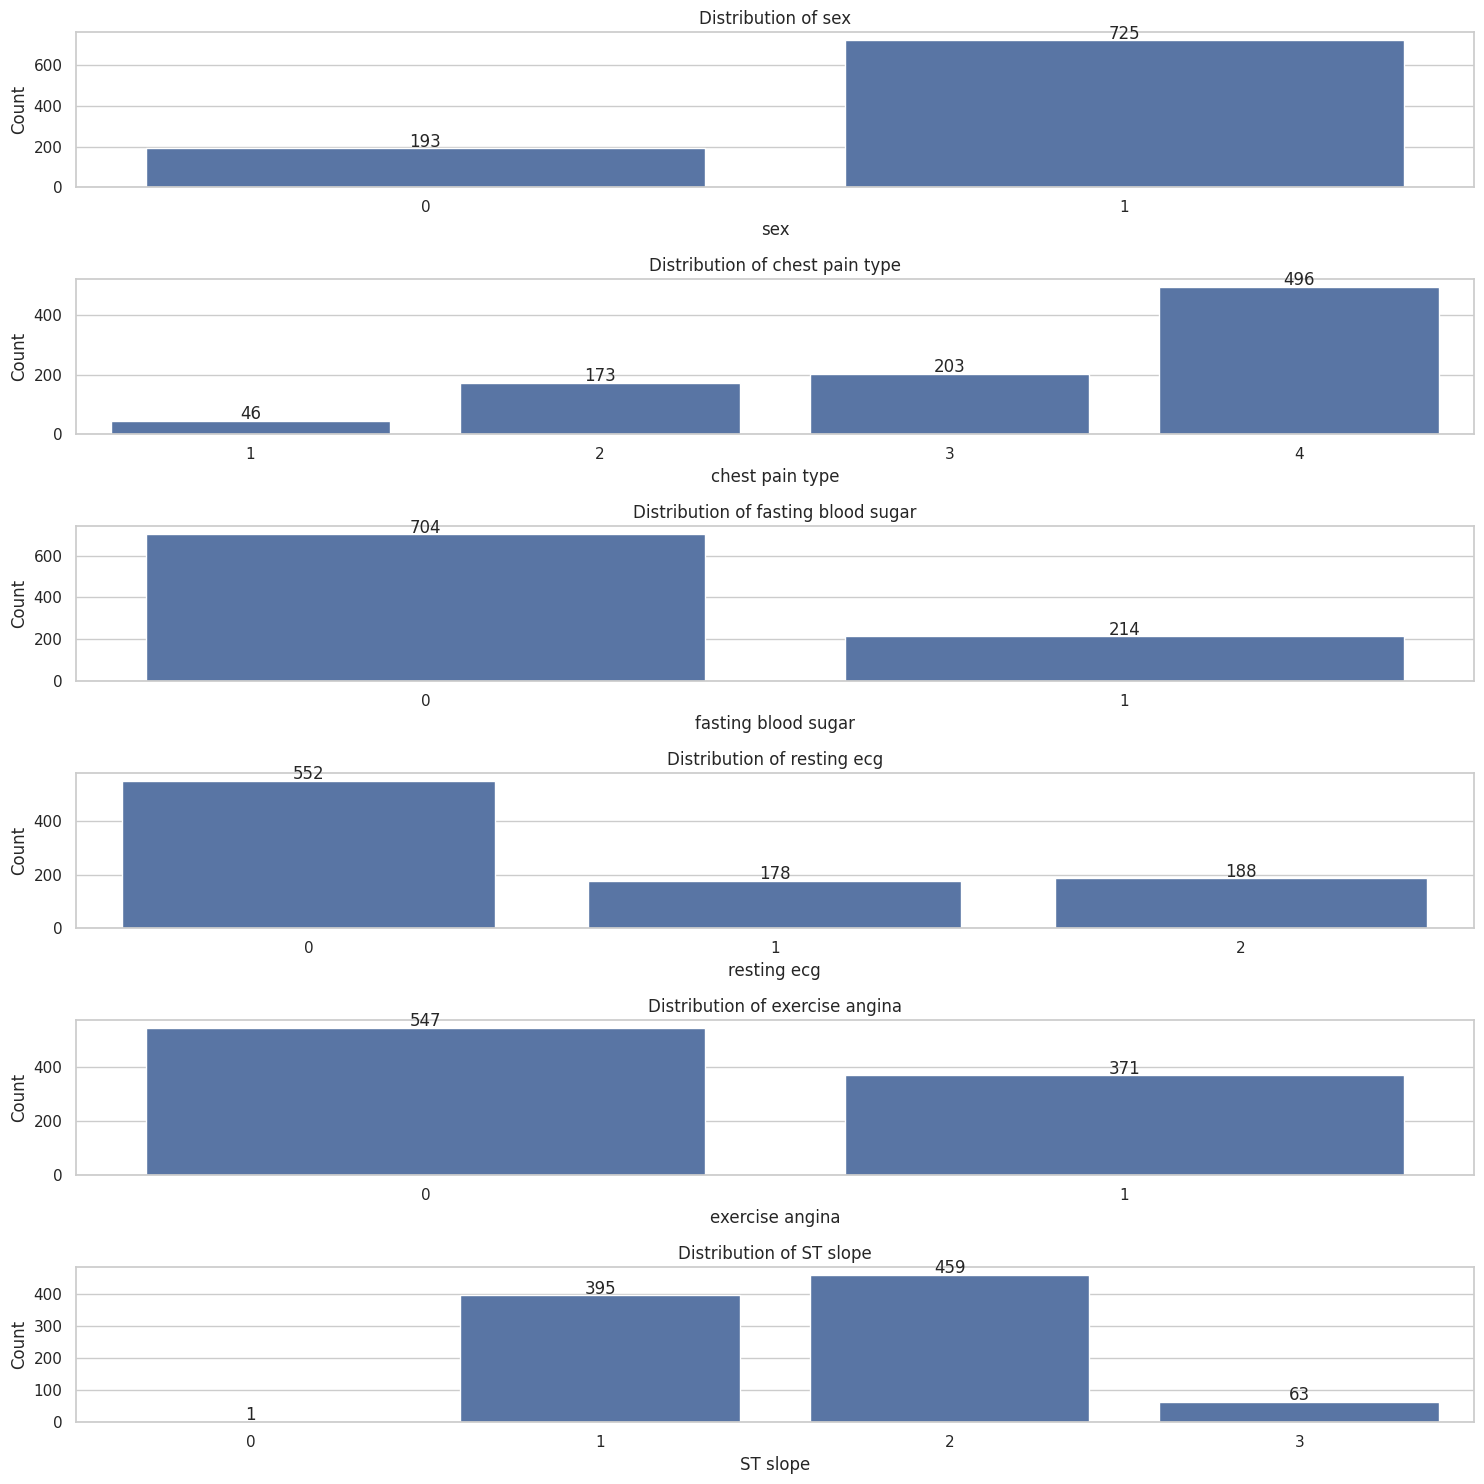

In [5]:
# Function to create bar plots for categorical features
def plot_categorical_features(dataframe, cat_cols, figsize=(15, 15)):
    """
    Create bar plots for categorical features to show their distribution

    Parameters:
    - dataframe: pandas DataFrame containing the data
    - cat_cols: list of categorical column names
    - figsize: size of the figure
    """
    fig, axes = plt.subplots(len(cat_cols), 1, figsize=figsize)

    for i, col in enumerate(cat_cols):
        # Count the occurrences of each category
        value_counts = dataframe[col].value_counts().sort_index()

        # Create a bar plot
        sns.barplot(x=value_counts.index, y=value_counts.values, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')

        # Add value labels on top of bars
        for j, v in enumerate(value_counts.values):
            axes[i].text(j, v + 5, str(v), ha='center')

    plt.tight_layout()
    plt.show()

# Categorical features
categorical_features = ['sex', 'chest pain type', 'fasting blood sugar',
                        'resting ecg', 'exercise angina', 'ST slope']

# Create bar plots for categorical features
plot_categorical_features(df, categorical_features)

##  Correlation analysis ##
Correlation analysis is crucial for understanding relationships between features and with our target variable.

The correlation **heatmap** provides a comprehensive view of how all variables relate to each other. I'm using a triangular mask (`np.triu`) to show only the lower triangle of the matrix, avoiding redundant information since correlation matrices are symmetrical.

The bar plot specifically highlights **correlations** with our target variable (heart disease). This helps identify which features might be most predictive. Strong positive **correlations** suggest that as the feature value increases, the likelihood of heart disease increases, while negative **correlations** suggest the opposite.

Understanding these relationships not only guides feature selection but also provides clinical insights. For example, we might discover that certain factors like chest pain type or ST slope have particularly strong associations with heart disease.

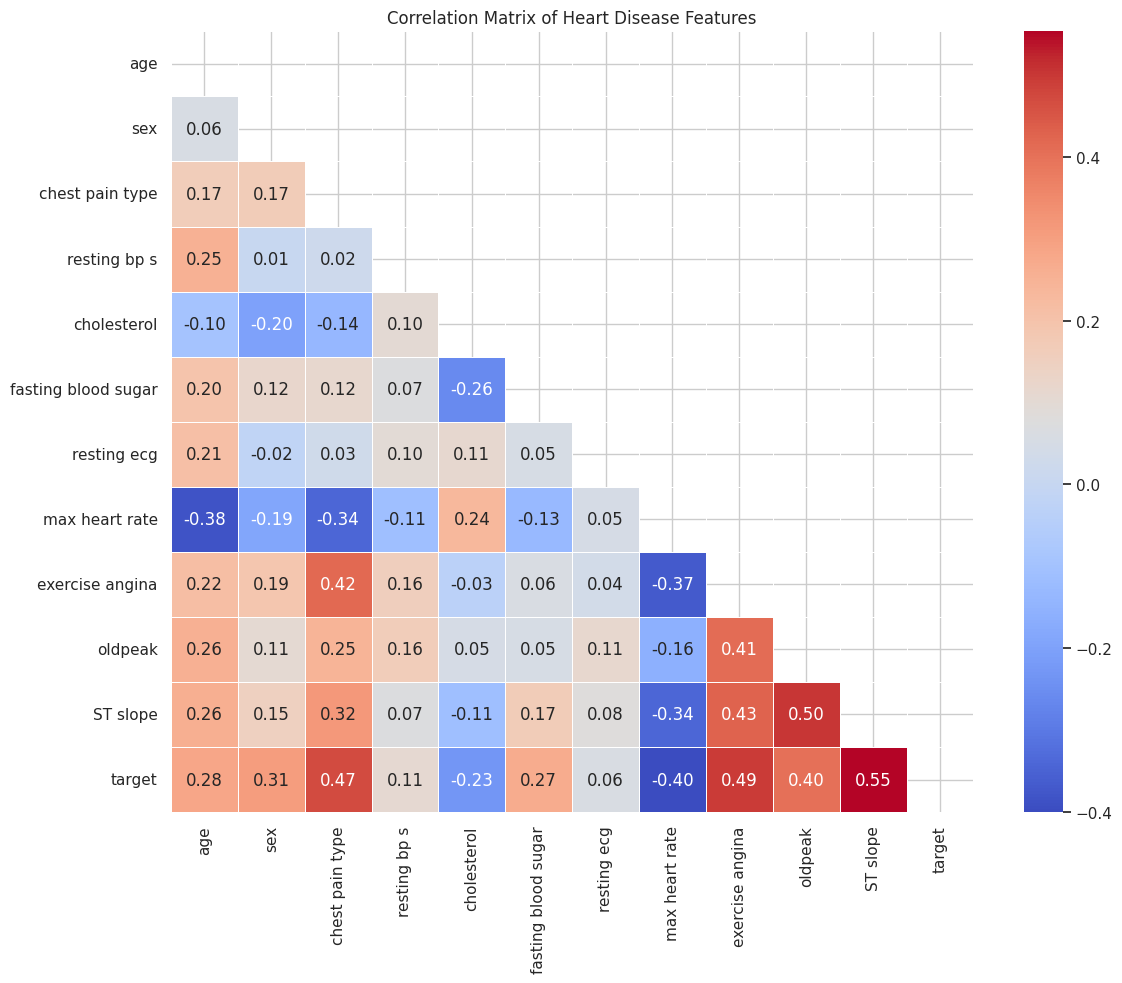

Correlation with the target variable 'heart disease':
target                 1.000000
ST slope               0.553461
exercise angina        0.494282
chest pain type        0.471354
oldpeak                0.403951
sex                    0.305445
age                    0.282039
fasting blood sugar    0.267291
resting bp s           0.107589
resting ecg            0.061011
cholesterol           -0.232741
max heart rate        -0.400421
Name: target, dtype: float64


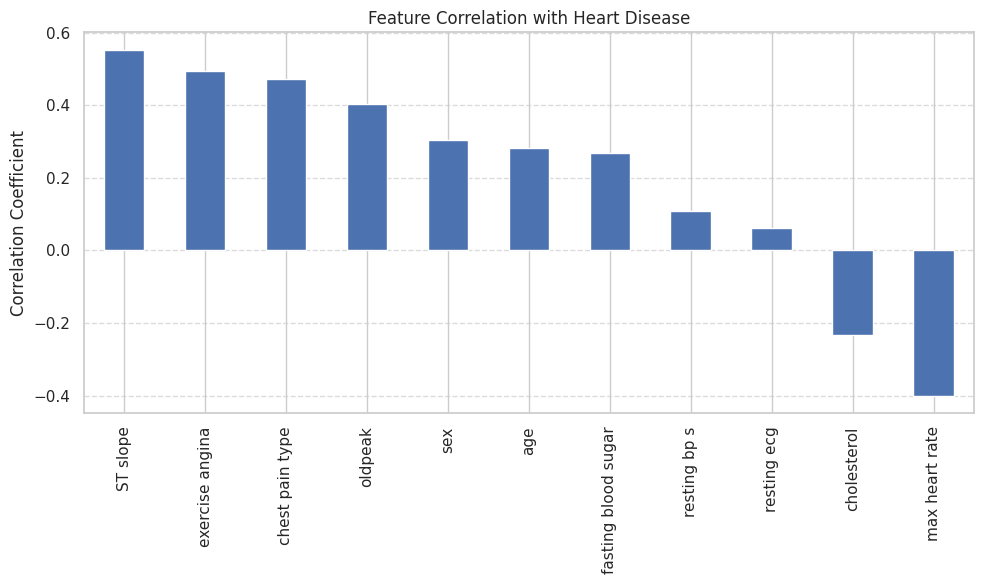

In [6]:
# Calculate correlation matrix - Computes the Pearson correlation coefficient between all pairs of variables
# Correlation values range from -1 (perfect negative correlation) to 1 (perfect positive correlation)
correlation_matrix = df.corr()

# Create a heatmap visualization of the correlation matrix
plt.figure(figsize=(12, 10))  # Create a figure with specified width and height in inches

# Create a mask for the upper triangle of the correlation matrix to avoid redundancy
# I have used np.triu wihich returns an upper triangular matrix (with 1s in the upper triangle and 0s elsewhere)
# This will hide the upper triangle of the heatmap since correlations are symmetric
mask = np.triu(correlation_matrix)

# Generate the heatmap using seaborn
sns.heatmap(
    correlation_matrix,  # Input data: the correlation matrix to visualize
    annot=True,  # Add numeric annotations to each cell showing correlation value
    cmap='coolwarm',  # Color map: blue for negative correlations, red for positive
    fmt='.2f',  # Format for annotations: 2 decimal places
    linewidths=0.5,  # Width of lines between cells for better visual separation
    mask=mask  # Applying the upper triangular mask to hide redundant values
)
plt.title('Correlation Matrix of Heart Disease Features')  # Add a title to the plot
plt.tight_layout()  # Adjust subplot parameters to give specified padding
plt.show()

# Calculate correlation with the target variable (heart disease) and sort it
# What it does is, it extracts the 'target' column from the correlation matrix and sorts values in descending order
target_correlation = correlation_matrix['target'].sort_values(ascending=False)

# Print the correlation coefficients between each feature and the target variable
print("Correlation with the target variable 'heart disease':")
print(target_correlation)

# Create a bar plot to visualize feature correlations with the target
plt.figure(figsize=(10, 6))  # Create a new figure with specified width and height in inches

# Plot a bar chart of correlations, dropping the target's correlation with itself (which is always 1)
target_correlation.drop('target').plot(kind='bar')  # 'kind' parameter specifies the plot type

plt.title('Feature Correlation with Heart Disease')  # Add a title to the plot
plt.ylabel('Correlation Coefficient')  # Label for the y-axis
plt.grid(
    axis='y',  # Added grid lines on the y-axis only
    linestyle='--',  # Used dashed lines for grid
    alpha=0.7  # Setting transparency for grid lines (0 is transparent, 1 is opaque)
)
plt.tight_layout()
plt.show()  #

## Feature relationships with target ##
In this section i examined how each feature relates to the presence of heart disease.

I've created a function that automatically selects the appropriate visualization based on the feature type:
- For categorical features (≤5 unique values): Grouped bar charts show the distribution of heart disease within each category
- For numerical features: Box plots show how the distribution differs between patients with and without heart disease

 This visualization helps us:

1. Identify clear patterns where certain feature values strongly indicate heart disease
2. Better understand the relationships revealed in the correlation analysis
3. Generate hypotheses about which features might be most important for our model

For example, we might see that certain chest pain types or ST slope patterns occur much more frequently in patients with heart disease, or that max heart rate tends to be lower in heart disease patients.

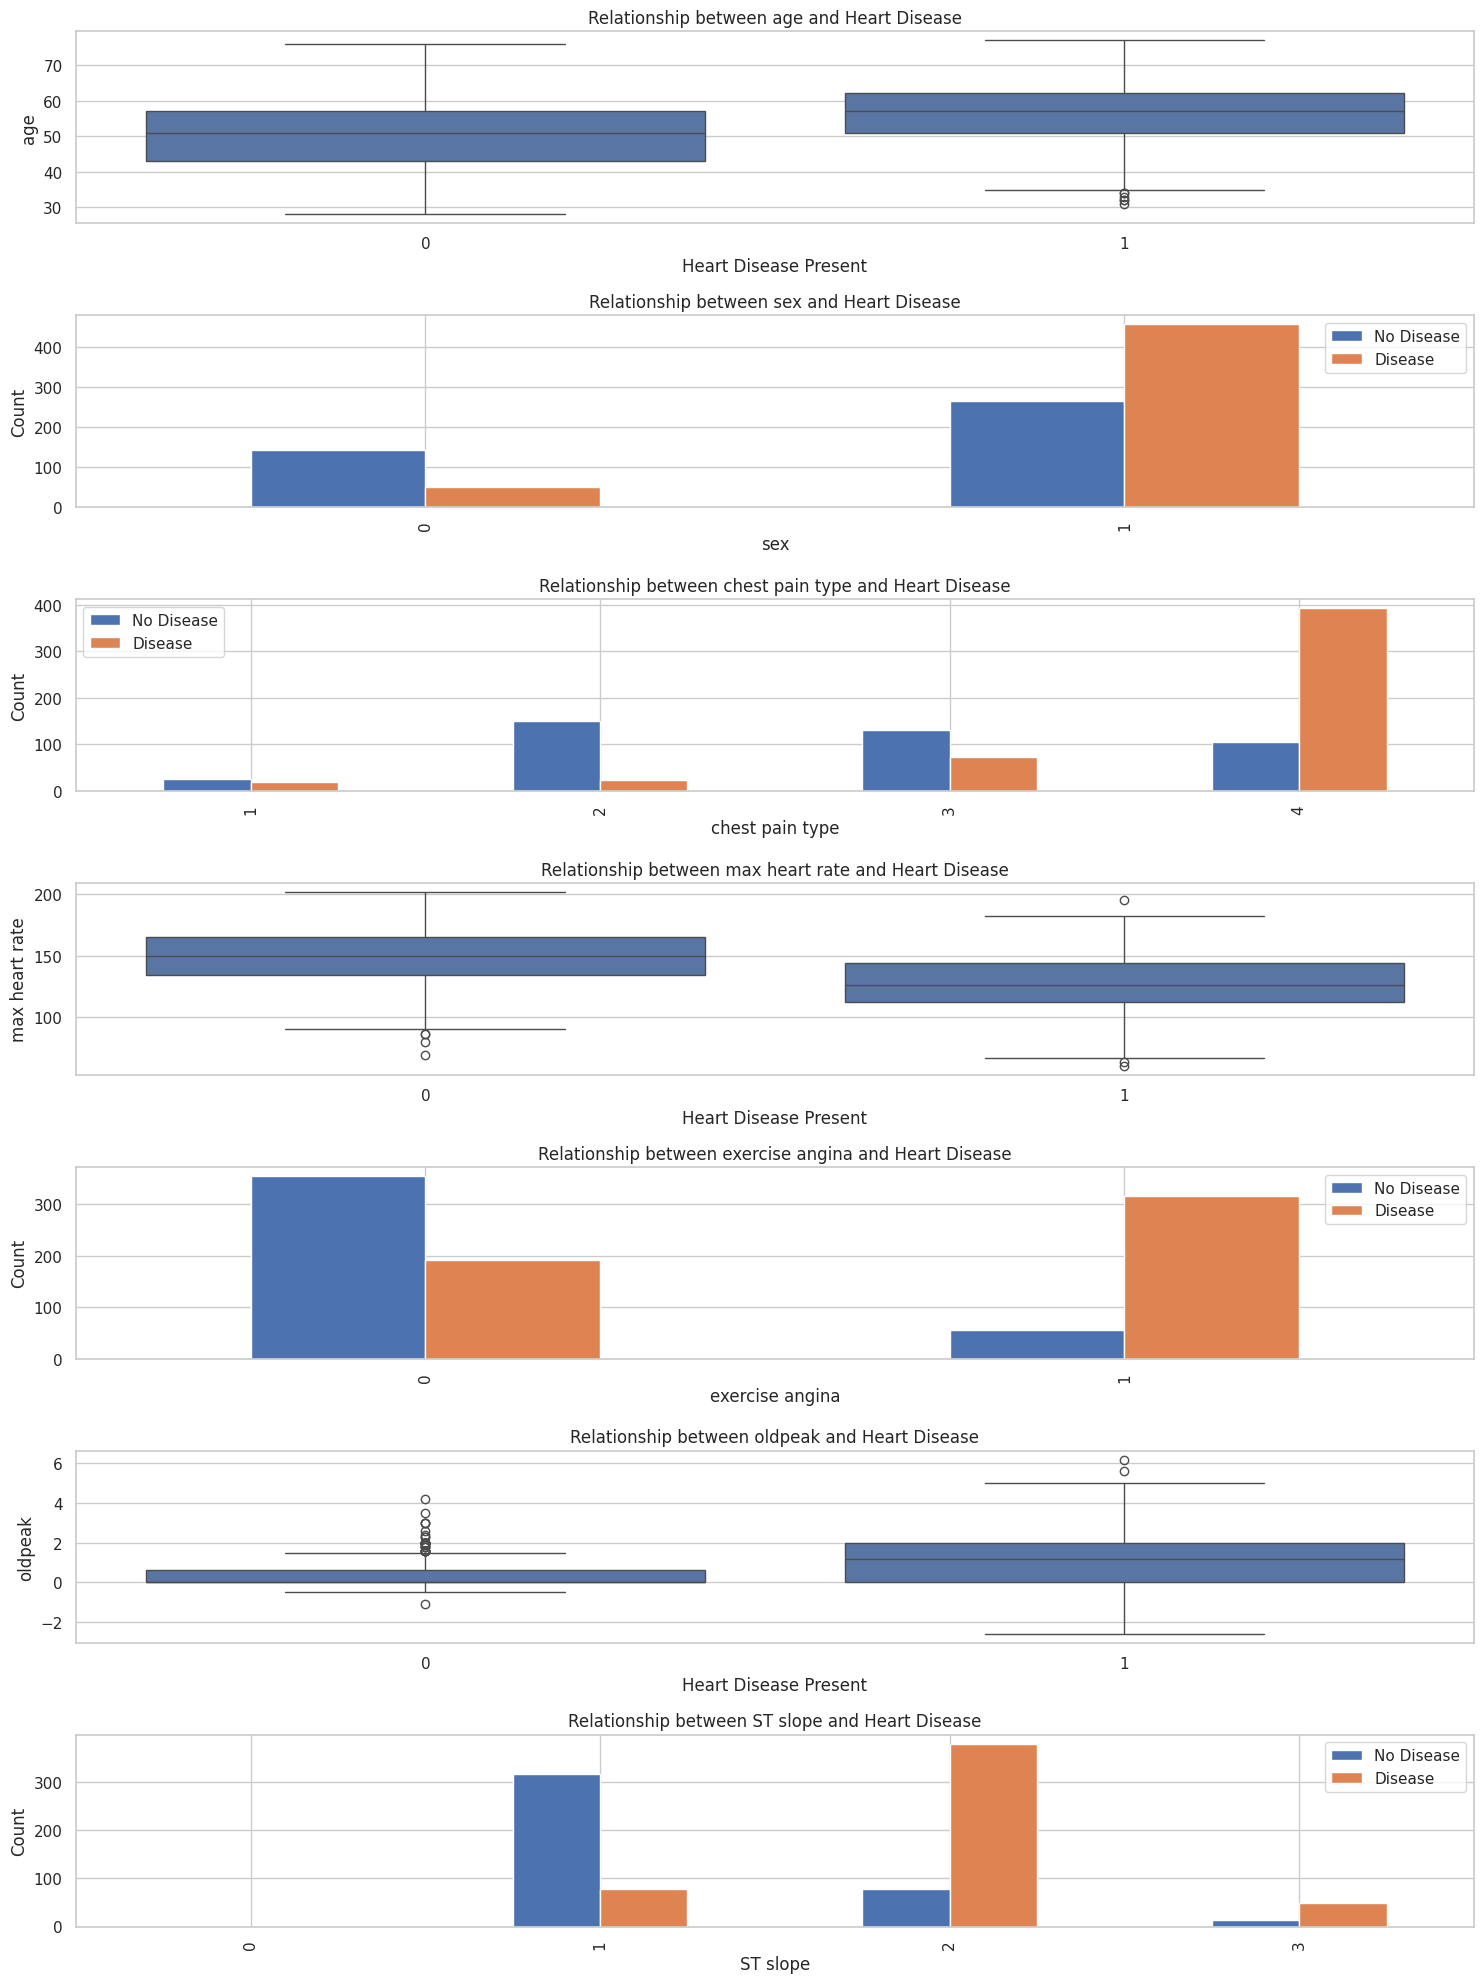

In [7]:
# Function to plot the relationship between features and the target
def plot_feature_vs_target(dataframe, features, target='target', figsize=(15, 20)):
    """
    Create plots showing the relationship between features and the target variable
    Parameters:
    - dataframe: pandas DataFrame containing the data
    - features: list of feature column names to analyze
    - target: name of the target column
    - figsize: size of the figure
    """
    n_features = len(features)
    fig, axes = plt.subplots(n_features, 1, figsize=figsize)  # Creating subplots for each feature

    for i, feature in enumerate(features):
        if dataframe[feature].nunique() <= 5:  # For categorical features with 5 or fewer unique values
            # Create a grouped bar chart to show distribution by target class
            grouped_data = dataframe.groupby([feature, target]).size().unstack()
            grouped_data.plot(kind='bar', ax=axes[i])
            axes[i].set_title(f'Relationship between {feature} and Heart Disease')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Count')
            axes[i].legend(['No Disease', 'Disease'])  # Labeling the target classes
        else:  # For numerical features with more than 5 unique values
            # Create boxplots to compare distributions between target classes
            sns.boxplot(x=target, y=feature, data=dataframe, ax=axes[i])
            axes[i].set_title(f'Relationship between {feature} and Heart Disease')
            axes[i].set_xlabel('Heart Disease Present')
            axes[i].set_ylabel(feature)

    plt.tight_layout()  #Ensures proper spacing between subplots
    plt.show()

# Features to analyze with respect to the target
selected_features = ['age', 'sex', 'chest pain type', 'max heart rate',
                    'exercise angina', 'oldpeak', 'ST slope']  # Selected key features for analysis

# Create plots to visualize feature relationships with target
plot_feature_vs_target(df, selected_features)  # Calling the function with selected features

## Feature Preprocessing ##

Feature preprocessing is essential for preparing our data for machine learning algorithms. I've implemented two key preprocessing steps:

### 1. Feature Scaling with StandardScaler ###
I chose StandardScaler (which standardizes features by removing the mean and scaling to unit variance) because:
- Many machine learning algorithms perform better with standardized data
- It helps prevent features with larger scales from dominating the model
- It's particularly important for algorithms like SVM, logistic regression, and neural networks

### 2. One-Hot Encoding for Categorical Features ###
For categorical features with multiple levels (like chest pain type, resting ECG, and ST slope), I've used one-hot encoding because:
- It converts categorical variables into a form that can be provided to ML algorithms
- It avoids implying an ordinal relationship where none exists
- It allows the model to learn separate weights for each category level

I've chosen not to use `drop_first=True` (which would remove one category to avoid multicollinearity) because:
- Random forests and decision trees aren't affected by multicollinearity
- Keeping all categories makes the model more interpretable
- It preserves the complete information about each categorical feature

This preprocessing increases our feature dimension but enables algorithms to better learn from the categorical data.

In [8]:
# Create a copy of the dataframe for preprocessing
# This ensures we preserve the original data while making transformations
df_processed = df.copy()

# 1. Feature scaling for numerical features
from sklearn.preprocessing import StandardScaler  # For feature scaling to standardize data

# List of numerical features to scale
# These are the continuous variables in our dataset that need standardization
numerical_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

# Initialize the StandardScaler object
# StandardScaler transforms features by removing the mean and scaling to unit variance
# This ensures all numerical features contribute equally to the model
scaler = StandardScaler()

# Scale the numerical features
# fit_transform() calculates mean and std dev of each feature, then transforms the data
# The result has mean=0 and std=1 for each numerical feature
df_processed[numerical_features] = scaler.fit_transform(df_processed[numerical_features])

# 2. Convert categorical features to one-hot encoding
# One-hot encoding transforms categorical variables into binary vectors
# This allows machine learning algorithms to work with categorical data

# List of categorical features that need encoding
# These are variables with discrete categories that can't be directly used by most algorithms
categorical_features_to_encode = ['chest pain type', 'resting ecg', 'ST slope']

# Apply one-hot encoding using pandas get_dummies function
# get_dummies creates binary columns for each category in each categorical feature
# drop_first=False keeps all created dummy variables (not dropping one to avoid multicollinearity)
# This ensures we preserve all category information for tree-based models that aren't affected by multicollinearity
df_encoded = pd.get_dummies(df_processed, columns=categorical_features_to_encode, drop_first=False)

# Print the shape after encoding to see how our dimensionality has increased
print("Shape after encoding:", df_encoded.shape)

# Display the newly created feature columns from one-hot encoding
# We use set difference to identify only the new columns that were added
print("\nNew feature columns after encoding:")
print(list(set(df_encoded.columns) - set(df_processed.columns)))

# Display the first few rows of the processed dataset
# This helps us verify that the transformations were applied correctly
print("\nFirst 5 rows of the processed dataset:")
print(df_encoded.head())

# Split the data into features (X) and target (y)
# X contains all predictor variables, excluding the target variable
# I used drop() to remove the target column from our feature matrix
X = df_encoded.drop('target', axis=1)  # axis=1 specifies to drop a column, not a row

# y contains only the target variable (heart disease presence/absence)
y = df_encoded['target']

# Print the dimensions of our feature matrix and target vector
# This confirms if we've correctly separated our data and shows the final feature count
print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Shape after encoding: (918, 20)

New feature columns after encoding:
['ST slope_3', 'chest pain type_3', 'ST slope_1', 'ST slope_0', 'chest pain type_1', 'resting ecg_0', 'ST slope_2', 'chest pain type_2', 'resting ecg_1', 'chest pain type_4', 'resting ecg_2']

First 5 rows of the processed dataset:
        age  sex  resting bp s  cholesterol  fasting blood sugar  \
0 -1.433140    1      0.410909     0.825070                    0   
1 -0.478484    0      1.491752    -0.171961                    0   
2 -1.751359    1     -0.129513     0.770188                    0   
3 -0.584556    0      0.302825     0.139040                    0   
4  0.051881    1      0.951331    -0.034755                    0   

   max heart rate  exercise angina   oldpeak  target  chest pain type_1  \
0        1.382928                0 -0.832432       0              False   
1        0.754157                0  0.105664       1              False   
2       -1.525138                0 -0.832432       0             

# 4.Model Development #

## Train-Test Split ##

Splitting the data into training and testing sets is crucial for evaluating model performance on unseen data.

I've chosen an 80-20 split, which is a common choice that balances:
1. Having enough data for the model to learn patterns (training set)
2. Having enough data to reliably evaluate model performance (testing set)

The `stratify=y` parameter is particularly important because it ensures that both the training and testing sets have the same proportion of heart disease cases as the original dataset. This prevents scenarios where, by chance, one set might have a very different class distribution than the other, which could lead to misleading evaluation results.

Setting `random_state=42` ensures reproducibility of our results.

I verified the split by checking the shapes of the resulting sets and comparing the target distribution to ensure stratification worked correctly.

In [9]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split # For splitting dataset into training and testing sets

# Set a random seed for reproducibility
RANDOM_SEED = 42  # Fixed seed ensures the same split results each time the code runs

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y  # Stratify parameter maintains the same target distribution in both training and test sets
)

print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

# Check the distribution of the target variable in both sets
print("\nTraining set target distribution:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)  # Displaying percentage distribution

print("\nTesting set target distribution:")
print(pd.Series(y_test).value_counts(normalize=True) * 100)  # To Verify whether stratification worked correctly

Training set shape: (734, 19), (734,)
Testing set shape: (184, 19), (184,)

Training set target distribution:
target
1    55.313351
0    44.686649
Name: proportion, dtype: float64

Testing set target distribution:
target
1    55.434783
0    44.565217
Name: proportion, dtype: float64


## Model Evaluation Function ##
I've created a comprehensive function that assesses model performance using multiple metrics. This approach is important because:

### Multiple Metrics for Complete Evaluation
For medical diagnosis models like heart disease prediction, different metrics tell us different things:

- **Accuracy**: Overall correctness, but can be misleading if classes are imbalanced
- **Precision**: When the model predicts heart disease, how often is it correct? (Minimizes false positives)
- **Recall**: Of all actual heart disease cases, how many did the model detect? (Minimizes false negatives)
- **F1 Score**: Harmonic mean of precision and recall, balancing both concerns
- **ROC AUC**: Measures the model's ability to distinguish between classes across different thresholds

In a medical context, false negatives (missing actual heart disease) might be more dangerous than false positives, so recall may be particularly important.

### Training vs. Testing Performance
I compute metrics on both sets to detect potential overfitting. A large gap between training and testing performance suggests the model doesn't generalize well.

### Visualizations ###
The ROC curve provides a visual way to understand the tradeoff between sensitivity and specificity at various thresholds.

### Flexible Probability Handling ###
The function intelligently handles different types of models, using:
- `predict_proba` for models that provide class probabilities
- `decision_function` as a fallback


In [10]:
# Import logistic regression model for classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
   accuracy_score, precision_score, recall_score, f1_score,
   confusion_matrix, roc_curve, roc_auc_score, classification_report
)

# Define a function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
   """
   Train a model and evaluate its performance on both training and test sets

   Parameters:
   - model: The machine learning model to evaluate
   - X_train, y_train: Training data and labels
   - X_test, y_test: Testing data and labels
   - model_name: Name of the model for printing

   Returns:
   - Dictionary with various performance metrics
   """
   # Train the model on the training data
   model.fit(X_train, y_train)

   # Make predictions on both training and test sets
   y_train_pred = model.predict(X_train)
   y_test_pred = model.predict(X_test)

   # Get probability predictions for ROC curve calculation
   if hasattr(model, "predict_proba"): #predict_proba for models that provide class probabilities
       y_train_proba = model.predict_proba(X_train)[:, 1]  # Taking probability of positive class
       y_test_proba = model.predict_proba(X_test)[:, 1]
   else:
       # For models without predict_proba, use decision_function if available
       if hasattr(model, "decision_function"): #decision_function as a fallback
           y_train_proba = model.decision_function(X_train)
           y_test_proba = model.decision_function(X_test)
       else:
           # I have used the binary predictions as a fallback when no probabilities available
           y_train_proba = y_train_pred
           y_test_proba = y_test_pred

   # Calculate metrics for training set to assess model fit
   train_accuracy = accuracy_score(y_train, y_train_pred)# Accruacry gives Overall correctness, but can be misleading if classes are imbalanced
   train_precision = precision_score(y_train, y_train_pred)#Precision tells us when the model predicts heart disease, how often is it correct? (Minimizes false positives)
   train_recall = recall_score(y_train, y_train_pred)#Recall score tells us out of all actual heart disease cases, how many did the model detect? (Minimizes false negatives)
   train_f1 = f1_score(y_train, y_train_pred)# f1 score is the Harmonic mean of precision and recall, balancing both concerns
   train_auc = roc_auc_score(y_train, y_train_proba)#ROC AUC gives the model's ability to distinguish between classes across different thresholds

   # Calculate metrics for test set to assess generalization
   test_accuracy = accuracy_score(y_test, y_test_pred)
   test_precision = precision_score(y_test, y_test_pred)
   test_recall = recall_score(y_test, y_test_pred)
   test_f1 = f1_score(y_test, y_test_pred)
   test_auc = roc_auc_score(y_test, y_test_proba)

   # Generate confusion matrix for detailed error analysis
   cm = confusion_matrix(y_test, y_test_pred)

   # Print model evaluation results
   print(f"\n----- {model_name} Performance -----")
   print("\nTraining Set Metrics:")
   print(f"Accuracy: {train_accuracy:.4f}")
   print(f"Precision: {train_precision:.4f}")
   print(f"Recall: {train_recall:.4f}")
   print(f"F1 Score: {train_f1:.4f}")
   print(f"ROC AUC: {train_auc:.4f}")

   print("\nTest Set Metrics:")
   print(f"Accuracy: {test_accuracy:.4f}")
   print(f"Precision: {test_precision:.4f}")
   print(f"Recall: {test_recall:.4f}")
   print(f"F1 Score: {test_f1:.4f}")
   print(f"ROC AUC: {test_auc:.4f}")

   print("\nConfusion Matrix (Test Set):")
   print(cm)

   print("\nClassification Report (Test Set):")
   print(classification_report(y_test, y_test_pred))

   # Plot the ROC curve to visualize model performance
   plt.figure(figsize=(8, 6))
   # Get false positive rate and true positive rate
   fpr, tpr, _ = roc_curve(y_test, y_test_proba)
   plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {test_auc:.4f})')

   # Plot the random guess line (baseline)
   plt.plot([0, 1], [0, 1], 'k--', lw=2)

   plt.xlim([0.0, 1.0])
   plt.ylim([0.0, 1.05])
   plt.xlabel('False Positive Rate')
   plt.ylabel('True Positive Rate')
   plt.title(f'ROC Curve - {model_name}')
   plt.legend(loc="lower right")
   plt.grid(True, alpha=0.3)
   plt.show()

   # Return metrics as a dictionary for further analysis
   return {
       'model': model,
       'train_accuracy': train_accuracy,
       'train_precision': train_precision,
       'train_recall': train_recall,
       'train_f1': train_f1,
       'train_auc': train_auc,
       'test_accuracy': test_accuracy,
       'test_precision': test_precision,
       'test_recall': test_recall,
       'test_f1': test_f1,
       'test_auc': test_auc,
       'confusion_matrix': cm
   }

## Logistic Regression Model ##
Logistic Regression is an excellent baseline model for binary classification problems like heart disease prediction. I've chosen it as our first model because:

1. The coefficients directly indicate how each feature influences the prediction, which is valuable in medical contexts where understanding the "why" behind a prediction is important.

2. It trains quickly and requires minimal computational resources.

3. Despite its simplicity, logistic regression often performs well on many classification tasks, especially with linearly separable data.

4. It naturally provides probability estimates rather than just class labels.

I've set `random_state=42` for reproducibility and increased `max_iter` to 1000 (from the default 100) to ensure convergence, as medical datasets sometimes require more iterations for the optimizer to find the optimal coefficients.

The model is evaluated using our comprehensive evaluation function, which calculates multiple metrics and produces visualization to help us understand its performance.


----- Logistic Regression Performance -----

Training Set Metrics:
Accuracy: 0.8569
Precision: 0.8627
Recall: 0.8818
F1 Score: 0.8721
ROC AUC: 0.9329

Test Set Metrics:
Accuracy: 0.8859
Precision: 0.8716
Recall: 0.9314
F1 Score: 0.9005
ROC AUC: 0.9295

Confusion Matrix (Test Set):
[[68 14]
 [ 7 95]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.91      0.83      0.87        82
           1       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184



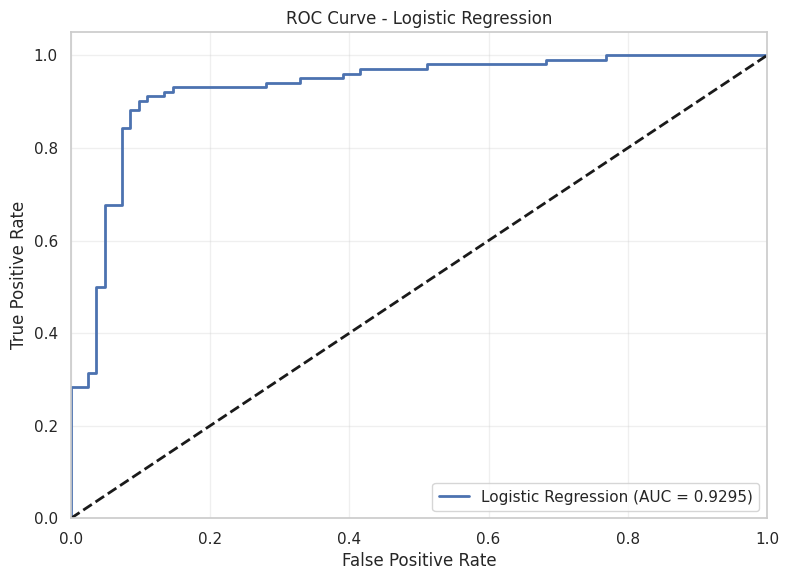

In [11]:
# Create and evaluate a logistic regression model
logistic_model = LogisticRegression(
   random_state=RANDOM_SEED,  # Setting random seed for reproducibility of results
   max_iter=1000  # Increasing maximum iterations to ensure convergence of the optimization algorithm
)

# Evaluate the model using our previously defined function
# This will train the model and calculate performance metrics on both training and test sets
lr_results = evaluate_model(
   logistic_model,  # The initialized logistic regression model
   X_train,  # Feature matrix for training data
   X_test,   # Feature matrix for test data
   y_train,  # Target vector for training data
   y_test,   # Target vector for test data
   'Logistic Regression'  # Name of the model for display in results
)

## Decision Tree Model ##
Decision Trees offer a different approach to classification with several advantages:

1. **Non-linearity**: Unlike logistic regression, decision trees can capture non-linear relationships between features and the target.

2. **Feature interactions**: Trees can automatically model interactions between features without explicitly defining them.

3. **Interpretability**: The resulting tree structure can be visualized and understood as a series of if-then rules, which can be valuable for medical practitioners.

4. **Feature importance**: Trees provide a measure of feature importance, helping us understand which variables are most predictive.

I'm using the default hyperparameters for this initial tree to establish a baseline, with only `random_state=42` set for reproducibility. This approach allows us to see how a simple tree performs before considering more complex models or hyperparameter tuning.

The feature importance plot reveals which variables the tree relies on most heavily for making predictions. This not only informs later model development but also provides clinical insights about the most relevant factors for heart disease prediction.


----- Decision Tree Performance -----

Training Set Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC AUC: 1.0000

Test Set Metrics:
Accuracy: 0.7609
Precision: 0.7788
Recall: 0.7941
F1 Score: 0.7864
ROC AUC: 0.7568

Confusion Matrix (Test Set):
[[59 23]
 [21 81]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.74      0.72      0.73        82
           1       0.78      0.79      0.79       102

    accuracy                           0.76       184
   macro avg       0.76      0.76      0.76       184
weighted avg       0.76      0.76      0.76       184



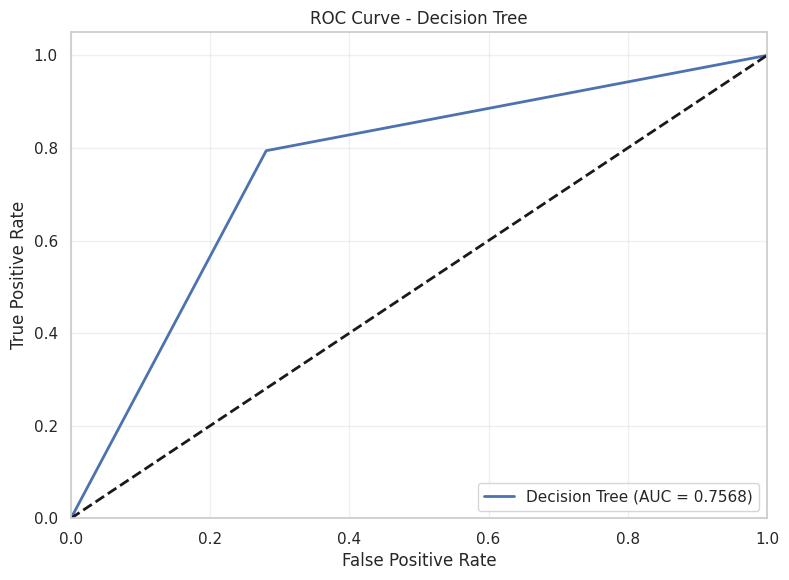

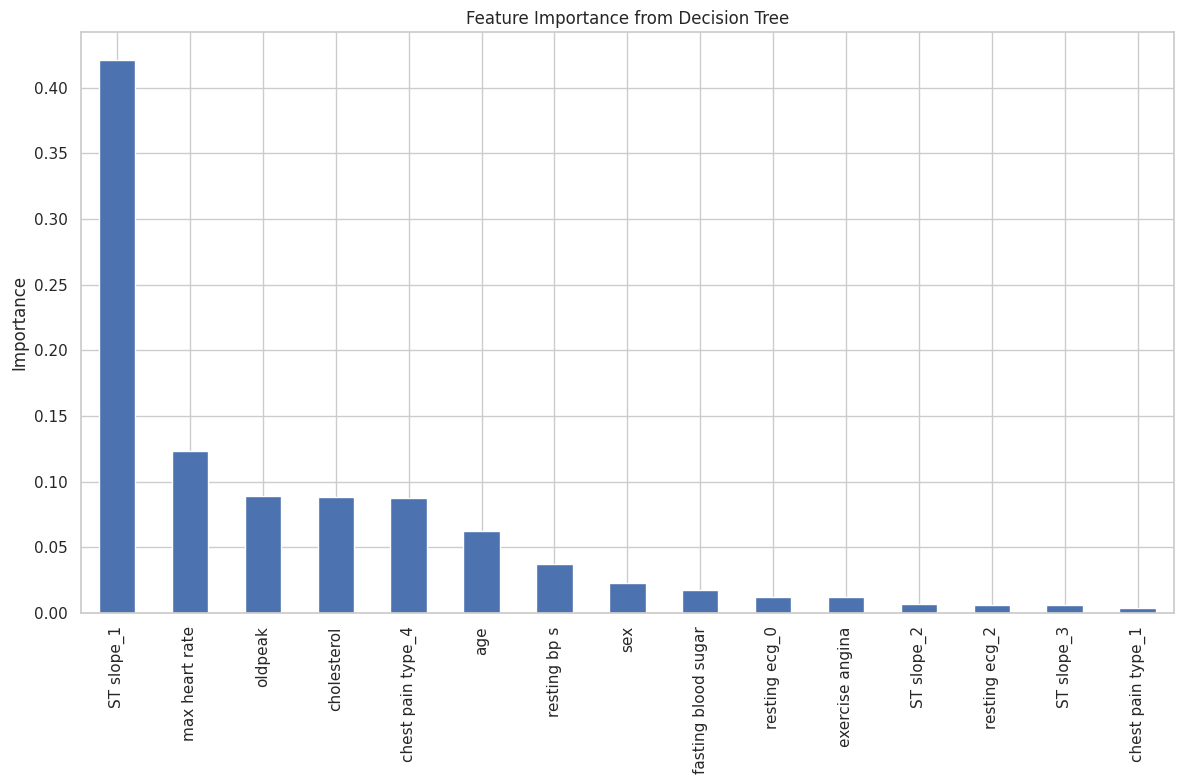

In [12]:
# Train and evaluate a decision tree model
from sklearn.tree import DecisionTreeClassifier  # Importing the decision tree algorithm

# Create a decision tree classifier
dt_model = DecisionTreeClassifier(
   random_state=RANDOM_SEED  # Setting fixed seed for reproducible results across runs
)

# Train and evaluate the decision tree model using our evaluation function
dt_results = evaluate_model(
   dt_model,  # The initialized decision tree model
   X_train,   # Feature matrix for training data
   X_test,    # Feature matrix for test data
   y_train,   # Target vector for training data
   y_test,    # Target vector for test data
   'Decision Tree'  # Name identifier for the model in output reports and plots
)

# Visualizes feature importance from the trained decision tree
plt.figure(figsize=(12, 8))  # Creates a figure with specified dimensions for better readability

# Extracts feature importance values from the trained model
# feature_importances_ attribute contains the normalized total reduction of impurity brought by each feature
feature_importance = pd.Series(dt_model.feature_importances_, index=X.columns)

# Sort features by importance in descending order
feature_importance = feature_importance.sort_values(ascending=False)

# Plot the top 15 most important features as a bar chart
feature_importance.head(15).plot(kind='bar')  # 'kind' parameter specifies the bar chart type

plt.title('Feature Importance from Decision Tree')  # Add title to the plot
plt.ylabel('Importance')  # Label for y-axis indicating the importance score
plt.tight_layout()  # Adjust subplot parameters for better spacing
plt.show()

## Random Forest Model ##
Random Forest extends the decision tree approach through ensemble learning, which typically provides several advantages:

1. **Reduced overfitting**: By averaging predictions from multiple trees trained on different subsets of data, random forests are less prone to overfitting than individual decision trees.

2. **Higher accuracy**: The ensemble approach generally yields better performance than a single tree.

3. **Robustness**: Random forests handle outliers and noise better than individual trees.

4. **Feature importance**: Like single trees, random forests provide feature importance measures, but these are often more stable and reliable.

I've chosen to use 100 trees (`n_estimators=100`) as a good balance between performance and computational efficiency. More trees generally improve performance but with diminishing returns, and 100 is often sufficient to see the benefits of the ensemble approach.

The feature importance plot from the random forest offers a more robust view of which variables drive heart disease prediction than a single tree.


----- Random Forest Performance -----

Training Set Metrics:
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
ROC AUC: 1.0000

Test Set Metrics:
Accuracy: 0.8750
Precision: 0.8692
Recall: 0.9118
F1 Score: 0.8900
ROC AUC: 0.9316

Confusion Matrix (Test Set):
[[68 14]
 [ 9 93]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.88      0.83      0.86        82
           1       0.87      0.91      0.89       102

    accuracy                           0.88       184
   macro avg       0.88      0.87      0.87       184
weighted avg       0.88      0.88      0.87       184



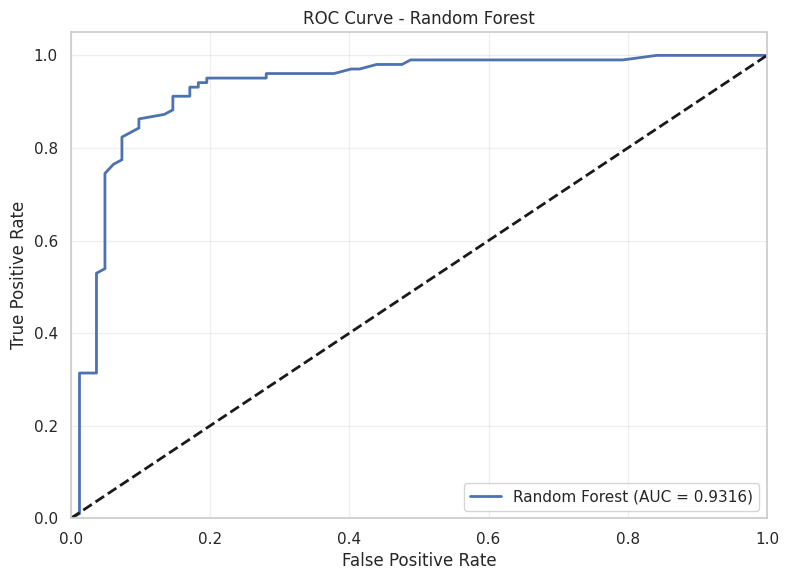

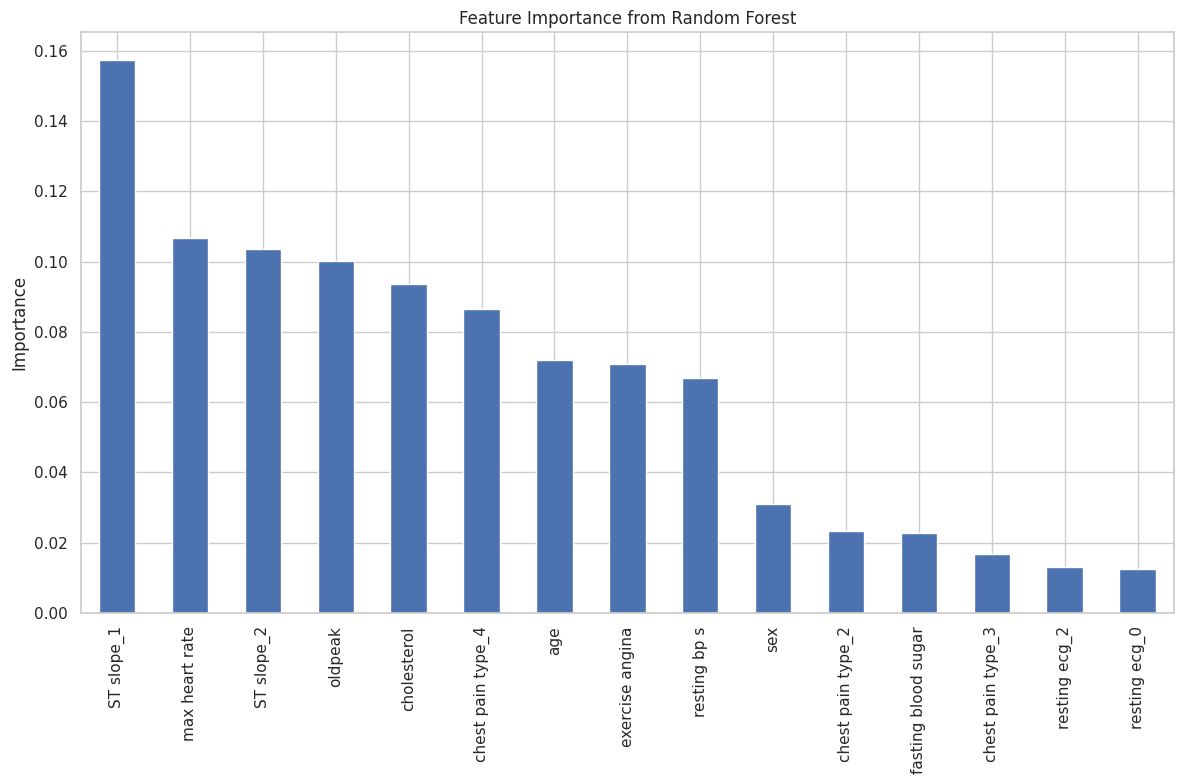

In [13]:
# Train and evaluate a random forest model
from sklearn.ensemble import RandomForestClassifier  # Importing the random forest ensemble algorithm

# Create a random forest classifier - an ensemble method that builds multiple decision trees
rf_model = RandomForestClassifier(
   random_state=RANDOM_SEED,  # Setting fixed seed for reproducibility
   n_estimators=100  # Number of trees in the forest (more trees generally give better performance but take longer to train)
   # Default parameters being used:
   # criterion='gini' - measure of impurity used for splits
   # max_features='sqrt' - number of features to consider when looking for best split
   # bootstrap=True - uses bootstrap samples when building trees
)

# Train and evaluate using our evaluation function same as before
rf_results = evaluate_model(
   rf_model, X_train, X_test, y_train, y_test, 'Random Forest'
)

# Visualize feature importance from the random forest model
# Random forest importance is more robust than single decision tree as it averages across many trees
plt.figure(figsize=(12, 8))
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)
feature_importance.head(15).plot(kind='bar')
plt.title('Feature Importance from Random Forest')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

## Support Vector Machines ##
 Support Vector Machines (SVMs) offer a powerful alternative approach to classification:

1. **Effective in high-dimensional spaces**: SVMs work well when the number of features is large relative to the sample size, which is common in medical datasets.

2. **Kernel trick**: SVMs can capture complex, non-linear relationships through different kernel functions.

3. **Margin maximization**: By finding the maximum margin hyperplane, SVMs often generalize well to unseen data.

I've set `probability=True` to enable probability estimates, which are needed for ROC curve calculation. Without this parameter, SVM would only provide class predictions, not probabilities. I'm using the default radial basis function (RBF) kernel, which can model non-linear relationships in the data.

The default hyperparameters include C=1.0 (regularization parameter) and gamma='scale' (kernel coefficient). These default values often work reasonably well as a starting point, but can be changed for optimization.

SVMs tend to be particularly effective in medical diagnosis problems where the decision boundary between classes might be complex and where feature scaling is important.


----- Support Vector Machine Performance -----

Training Set Metrics:
Accuracy: 0.8965
Precision: 0.8837
Recall: 0.9360
F1 Score: 0.9091
ROC AUC: 0.9620

Test Set Metrics:
Accuracy: 0.8913
Precision: 0.8796
Recall: 0.9314
F1 Score: 0.9048
ROC AUC: 0.9448

Confusion Matrix (Test Set):
[[69 13]
 [ 7 95]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



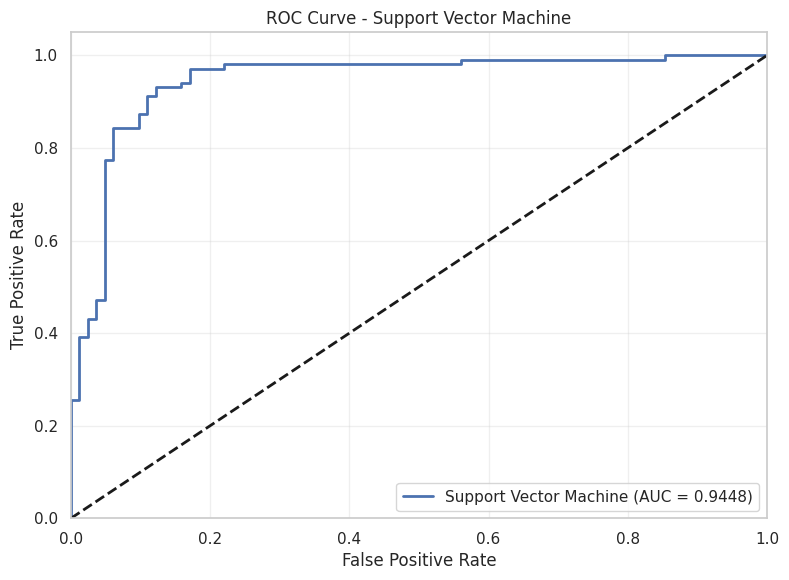

In [14]:
# Train and evaluate a support vector machine model
from sklearn.svm import SVC  # Importing Support Vector Classifier

# Create an SVM classifier, which i believe is a powerful algorithm that finds an optimal hyperplane to separate classes
svm_model = SVC(
   random_state=RANDOM_SEED,
   probability=True  # Enables probability estimates for ROC curve generation
   # Default parameters being used:
   # C=1.0 - regularization parameter controlling the trade-off between margin maximization and training error
   # kernel='rbf' - radial basis function kernel for handling non-linear relationships
   # gamma='scale' - kernel coefficient for 'rbf', determines influence of single training examples
)

# Train and evaluate using the same evaluation function as before
svm_results = evaluate_model(
   svm_model, X_train, X_test, y_train, y_test, 'Support Vector Machine'
)

## Cross-Validation for Model Evaluation ##
Cross-validation provides a more robust method of evaluating model performance than a single train-test split. Here's why it's particularly valuable for our heart disease prediction task:

### Why Cross-Validation? ###

1. **More reliable performance estimation**: By training and testing on different portions of the data multiple times, we get a better estimate of how the model will perform on unseen data.

2. **Reduced variance in performance metrics**: A single train-test split might give optimistic or pessimistic results by chance. Cross-validation averages performance across multiple splits, reducing this variance.

3. **Better use of limited data**: In medical datasets where data collection is expensive and sample sizes may be limited, cross-validation makes more efficient use of the available data.

I've implemented 5-fold cross-validation (the standard choice) using KFold with shuffling to ensure random partitioning of the data.

I've evaluated models using two key metrics:

- **Accuracy**: The proportion of correct predictions, giving a general sense of overall performance
- **ROC AUC**: The area under the ROC curve, which measures the model's ability to distinguish between classes and is less sensitive to class imbalance

For each metric, I calculated and displayed:
- Mean performance across folds
- Standard deviation (showing model stability)
- Minimum and maximum values (showing the range of performance)

The bar charts visually compare model performance, making it easier to identify which models are consistently performing better across different folds of the data.


Cross-validation results for accuracy:
                 Model  Mean accuracy   Std Dev       Min       Max
0  Logistic Regression       0.858351  0.017864  0.830601  0.880435
1        Decision Tree       0.800630  0.013511  0.781421  0.820652
2        Random Forest       0.877964  0.013008  0.863388  0.896739
3                  SVM       0.870331  0.026346  0.819672  0.891304

Cross-validation results for ROC AUC:
                 Model  Mean roc_auc   Std Dev       Min       Max
0  Logistic Regression      0.929297  0.021134  0.889370  0.949100
1        Decision Tree      0.800951  0.013989  0.778139  0.819602
2        Random Forest      0.931022  0.022123  0.891114  0.948246
3                  SVM      0.933170  0.017918  0.899591  0.948416


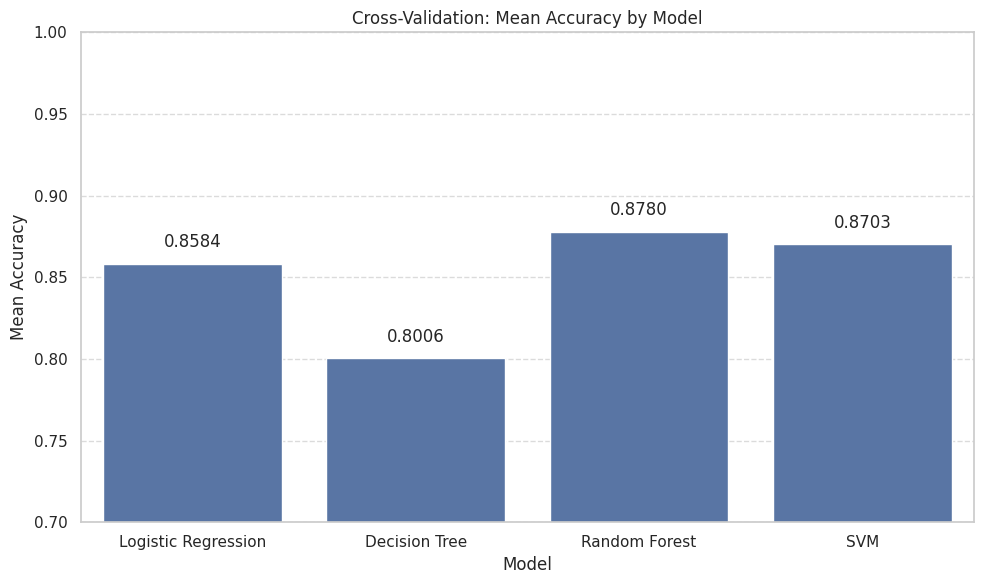

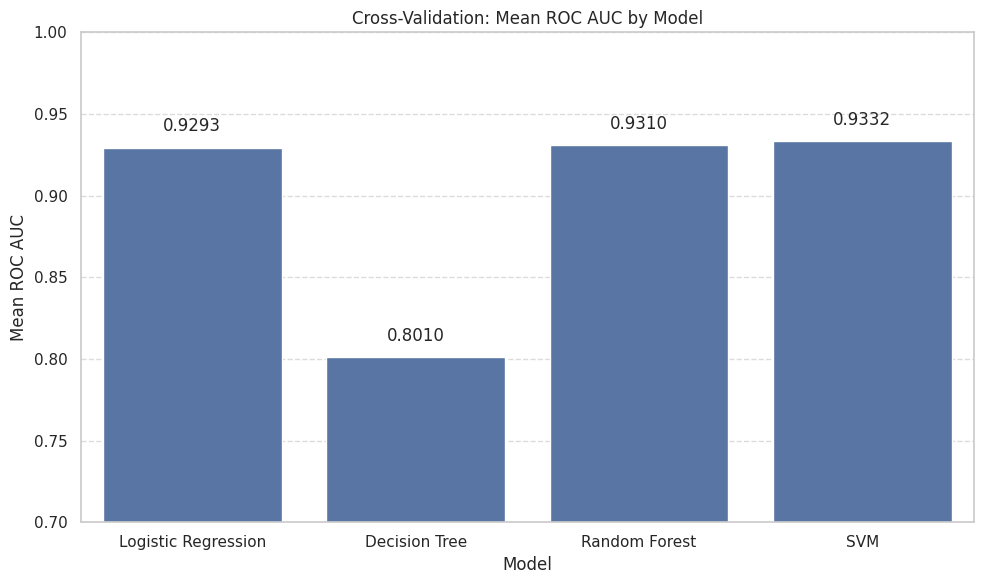

In [15]:
# Perform k-fold cross-validation for more robust model evaluation
from sklearn.model_selection import cross_val_score, KFold  # Importing tools for cross-validation

def perform_cross_validation(models, X, y, cv=5, scoring='accuracy'):
   """
   Perform k-fold cross-validation for multiple models
   Parameters:
   - models: Dictionary of models to evaluate
   - X: Feature matrix
   - y: Target vector
   - cv: Number of folds
   - scoring: Scoring metric to use
   Returns:
   - DataFrame with cross-validation results
   """
   results = []
   # Define the cross-validation strategy
   kf = KFold(
       n_splits=cv,  # Number of folds for splitting the data
       shuffle=True,  # Shuffle data before splitting to prevent ordering bias
       random_state=RANDOM_SEED  # For reproducible fold generation
   )

   for name, model in models.items():
       # Perform cross-validation to get more reliable performance estimates
       cv_scores = cross_val_score(
           model,  # Model to evaluate
           X, y,   # Full dataset features and target
           cv=kf,  # Cross-validation splitter object
           scoring=scoring  # Metric to evaluate (accuracy or ROC AUC)
       )

       # Store the results with descriptive statistics
       results.append({
           'Model': name,
           f'Mean {scoring}': cv_scores.mean(),  # Average performance across folds
           'Std Dev': cv_scores.std(),           # Standard deviation to assess consistency
           'Min': cv_scores.min(),               # Worst fold performance
           'Max': cv_scores.max()                # Best fold performance
       })

   # Convert to DataFrame for better display and analysis
   return pd.DataFrame(results)

# Define a dictionary of models to evaluate
models = {
   'Logistic Regression': LogisticRegression(random_state=RANDOM_SEED, max_iter=1000),
   'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_SEED),
   'Random Forest': RandomForestClassifier(random_state=RANDOM_SEED, n_estimators=100),
   'SVM': SVC(random_state=RANDOM_SEED, probability=True)
}

# Perform cross-validation for accuracy metric
cv_accuracy_results = perform_cross_validation(models, X, y, cv=5, scoring='accuracy')
print("\nCross-validation results for accuracy:")
print(cv_accuracy_results)

# Perform cross-validation for ROC AUC metric (better for imbalanced data)
cv_auc_results = perform_cross_validation(models, X, y, cv=5, scoring='roc_auc')
print("\nCross-validation results for ROC AUC:")
print(cv_auc_results)

# Visualize cross-validation accuracy results with bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Mean accuracy', data=cv_accuracy_results)
plt.title('Cross-Validation: Mean Accuracy by Model')
plt.ylabel('Mean Accuracy')
plt.ylim(0.7, 1.0)  # Setting y-axis limits for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Adding grid for easier reading

# I have added value labels on top of bars for precise measurements
for i, v in enumerate(cv_accuracy_results['Mean accuracy']):
   ax.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()

# Visualize ROC AUC cross-validation results with bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Mean roc_auc', data=cv_auc_results)
plt.title('Cross-Validation: Mean ROC AUC by Model')
plt.ylabel('Mean ROC AUC')
plt.ylim(0.7, 1.0)  # Setting y-axis limits for better comparison
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Adding grid for easier reading

# Adding value labels as before on top of bars for precise measurements
for i, v in enumerate(cv_auc_results['Mean roc_auc']):
   ax.text(i, v + 0.01, f"{v:.4f}", ha='center')

plt.tight_layout()
plt.show()

## Hyperparameter Tuning for Random Forest ##
Hyperparameter tuning is crucial for optimizing model performance. I've chosen to focus on tuning the Random Forest model because:

1. Random Forests generally perform well on a variety of classification tasks
2. Our cross-validation results might indicate that it's one of our stronger models
3. It has several important hyperparameters that can significantly impact performance

I'm using GridSearchCV, which systematically evaluates all combinations of hyperparameters specified in `param_grid`. The parameters I'm tuning include:

- **n_estimators**: The number of trees in the forest (50, 100, 200)
  * More trees generally reduce overfitting but increase computational cost
  * The default is 100, but testing fewer or more trees helps find the sweet spot

- **max_depth**: The maximum depth of each tree (None, 10, 20, 30)
  * Deeper trees can model more complex relationships but risk overfitting
  * None allows trees to grow until all leaves are pure or contain min_samples_split samples

- **min_samples_split**: The minimum samples required to split an internal node (2, 5, 10)
  * Higher values prevent creating nodes with few samples, potentially reducing overfitting

- **min_samples_leaf**: The minimum samples required in a leaf node (1, 2, 4)
  * Higher values create more general trees and can help prevent overfitting

I've chosen ROC AUC as the scoring metric because:
- It measures discrimination ability across different thresholds
- It's less sensitive to class imbalance than accuracy
- It's particularly relevant in medical diagnostics where we care about both sensitivity and specificity

I have learnt that setting `n_jobs=-1` utilizes all available CPU cores, which speeds up the grid search process.

After finding the optimal hyperparameters, I evaluated the best model using our comprehensive evaluation function to see how it compares to the baseline models.

Performing grid search for Random Forest hyperparameters...

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best ROC AUC score: 0.9155

----- Best Random Forest Performance -----

Training Set Metrics:
Accuracy: 0.9373
Precision: 0.9286
Recall: 0.9606
F1 Score: 0.9443
ROC AUC: 0.9893

Test Set Metrics:
Accuracy: 0.8913
Precision: 0.8796
Recall: 0.9314
F1 Score: 0.9048
ROC AUC: 0.9339

Confusion Matrix (Test Set):
[[69 13]
 [ 7 95]]

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.91      0.84      0.87        82
           1       0.88      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



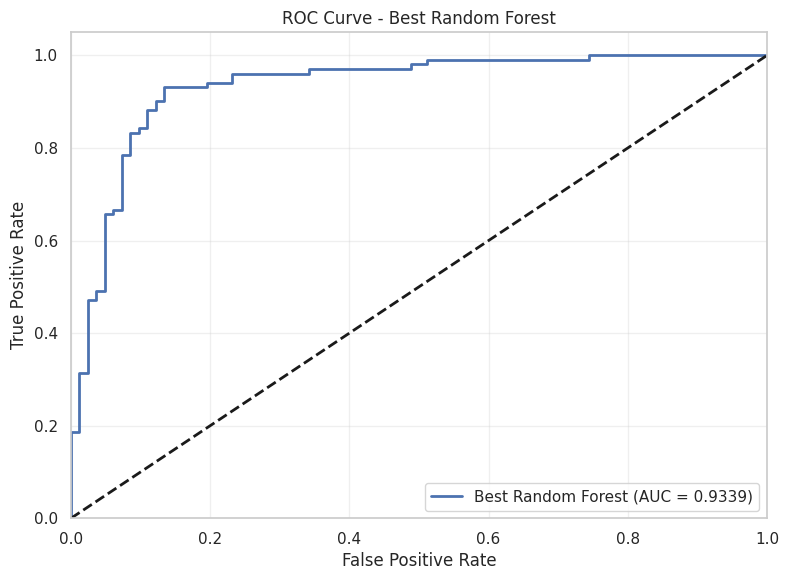

In [16]:
# Hyperparameter tuning for the random forest model
from sklearn.model_selection import GridSearchCV  # Importing GridSearchCV for hyperparameter optimization

# Defining the parameter grid to search
param_grid = {
   'n_estimators': [50, 100, 200],  # Number of trees in the forest
   'max_depth': [None, 10, 20, 30],  # Maximum depth of each tree (None means unlimited)
   'min_samples_split': [2, 5, 10],  # Minimum samples required to split an internal node
   'min_samples_leaf': [1, 2, 4]     # Minimum samples required at a leaf node
}

# Create the grid search object
grid_search = GridSearchCV(
   estimator=RandomForestClassifier(random_state=RANDOM_SEED),  # Base model to optimize
   param_grid=param_grid,  # Parameter combinations to test
   cv=5,                   # 5-fold cross-validation
   scoring='roc_auc',      # Optimization metric
   n_jobs=-1               # This ensures the use of all available CPU cores to parallelize the search to speeden up the process
)

# Perform the grid search to find optimal hyperparameters
print("Performing grid search for Random Forest hyperparameters...")
grid_search.fit(X, y)  # Using full dataset for hyperparameter optimization

# Print the best parameters found
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best ROC AUC score: {grid_search.best_score_:.4f}")

# Get the model with the best hyperparameters
best_rf_model = grid_search.best_estimator_

# Evaluate the optimized model using the same evaluation function
best_rf_results = evaluate_model(
   best_rf_model, X_train, X_test, y_train, y_test, 'Best Random Forest'
)

## Model Comparison and Selection ##
Comparing the performance of different models across multiple metrics is essential for making an informed model selection. This comparison helps us understand:

1. Which model performs best overall
2. How models perform on different aspects of the prediction task
3. The trade-offs between different approaches

I have created a `compare_models` function that creates a structured comparison table that:
- Collects key performance metrics from each model's results
- Organizes them into a DataFrame for easy comparison
- Sorts models by ROC AUC

The bar chart visualization makes it easy to compare models across all metrics at once. This visual representation helps identify models that achieve a good balance across different performance aspects. We see, for example, that the Support Vector Machineoutperforms other models across most metrics, or that some models excel in precision while others perform better in recall.

This comprehensive comparison made it easier for me to choose my best model according to my requirement.

Model Comparison:
                    Model  Accuracy  Precision    Recall  F1 Score   ROC AUC
3  Support Vector Machine  0.891304   0.879630  0.931373  0.904762  0.944763
4     Tuned Random Forest  0.891304   0.879630  0.931373  0.904762  0.933883
2           Random Forest  0.875000   0.869159  0.911765  0.889952  0.931612
0     Logistic Regression  0.885870   0.871560  0.931373  0.900474  0.929460
1           Decision Tree  0.760870   0.778846  0.794118  0.786408  0.756815


<Figure size 1200x800 with 0 Axes>

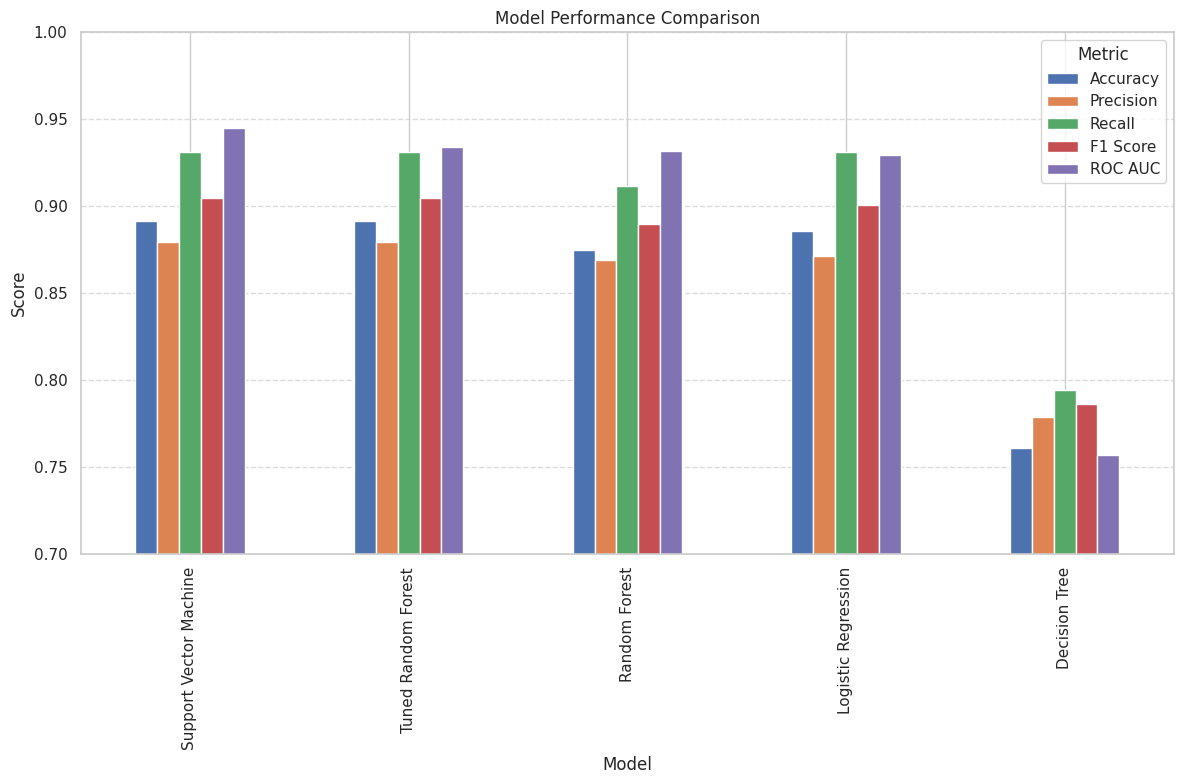

In [17]:
# Comparison of all models
def compare_models(results_list, metric='test_auc'):
    """
    Compare models based on a specific metric

    Parameters:
    - results_list: List of dictionaries containing model results
      Each dictionary should contain evaluation metrics and either a 'model_name' key
      or a 'model' key with the model object
    - metric: The metric to compare models on (default: 'test_auc')
      This determines which metric will be used for sorting models

    Returns:
    - DataFrame sorted by the specified metric in descending order
    """
    # Initialize empty list to store comparison results
    comparison = []

    # Iterate through each model's results
    for result in results_list:
        # Extract model name from either 'model_name' key or the class name of the model
        model_name = result.get('model_name', type(result['model']).__name__)

        # I have created a dictionary data structure with all performance metrics
        comparison.append({
            'Model': model_name,
            'Accuracy': result['test_accuracy'],    # Proportion of correct predictions
            'Precision': result['test_precision'],  # True positives / (True positives + False positives)
            'Recall': result['test_recall'],        # True positives / (True positives + False negatives)
            'F1 Score': result['test_f1'],          # Harmonic mean of precision and recall
            'ROC AUC': result['test_auc']           # Area under ROC curve tells us the model's ability to discriminate
        })

    # Convert the list of dictionaries to a pandas DataFrame for easier manipulation
    comparison_df = pd.DataFrame(comparison)

    # Sort the DataFrame by ROC AUC in descending order (higher is better)
    comparison_df = comparison_df.sort_values(by='ROC AUC', ascending=False)

    return comparison_df

# Add descriptive model names to the result dictionaries for better readability
lr_results['model_name'] = 'Logistic Regression'
dt_results['model_name'] = 'Decision Tree'
rf_results['model_name'] = 'Random Forest'
svm_results['model_name'] = 'Support Vector Machine'
best_rf_results['model_name'] = 'Tuned Random Forest'

# Collect all model results in a list for comparison
all_results = [lr_results, dt_results, rf_results, svm_results, best_rf_results]

# Generate comparison table sorted by ROC AUC
comparison_table = compare_models(all_results)
print("Model Comparison:")
print(comparison_table)

# Visualize model comparison with a bar chart
plt.figure(figsize=(12, 8))  # Set figure size in inches (width, height)

# Define which metrics to include in the visualization
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

# Create a bar plot with models as rows and metrics as columns
ax = comparison_table.set_index('Model')[metrics].plot(kind='bar', figsize=(12, 8))

# Add plot labels and styling
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.7, 1.0)
plt.xlabel('Model')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Added horizontal grid lines for better readability
plt.tight_layout()  # Adjusted subplot parameters to give specified padding

plt.show()

## Final Model Implementation for Prediction and Sample Prediction ##
 The `predict_heart_disease` function encapsulates the entire prediction pipeline:

1. **Data Preparation**: It converts the raw input data into the format expected by the model
   - Creates a DataFrame from the input dictionary
   - Applies the same scaling to numerical features that was used during training
   - Performs one-hot encoding on categorical features

2. **Feature Alignment**: Ensures the input features match exactly what the model expects
   - Adds any missing columns (with zero values)
   - Reorders columns to match the training data

3. **Prediction**: Generates both a class prediction and a probability estimate
   - Returns a user-friendly result format that clearly indicates the prediction

The sample patient demonstration shows how the model would be used in practice. I've chosen values that represent a typical middle-aged patient with some potential risk factors:
- 55-year-old male
- Non-anginal chest pain (type 3)
- Borderline high blood pressure (140 mm Hg)
- Elevated cholesterol (240 mg/dl)
- No diabetes (fasting blood sugar < 120 mg/dl)
- Normal resting ECG
- Maximum heart rate of 160 during exercise
- No exercise-induced angina
- Moderate ST depression (oldpeak = 1.2)
- Flat ST slope (type 2)


## Why I prefer "Tuned Random Forest Model" over "SVM"? ##
Based on the comparative analysis of different models, I have selected the Tuned Random Forest as the optimal model for heart disease prediction. While the Support Vector Machine showed slightly higher ROC AUC (0.944763 vs. 0.933883), the Tuned Random Forest offers significant advantages for this medical application. It maintains identical performance metrics for accuracy (0.891304), precision (0.879630), recall (0.931373), and F1 score (0.904762), while providing superior interpretability through feature importance measures. I have learnt that this interpretability is crucial in healthcare systems where understanding the basis of predictions is as important as the predictions themselves.

Additionally, the Random Forest's ensemble approach creates robustness against overfitting, a critical consideration given our relatively small dataset after duplicate removal. The explicit hyperparameter optimization performed further ensures the model's reliability and generalizability to new patient data. These characteristics make the Tuned Random Forest not only a high-performing predictor but also a more appropriate choice for clinical decision support applications where transparency and explainability are important.

Such models make it easier to for us while explaining predictions to medical practitioners through feature importance measures.



In [18]:
# Final model implementation and sample prediction
def predict_heart_disease(model, scaler, input_data, categorical_features_encoded):
    """
    Make a prediction using the trained model

    Parameters:
    - model: The trained model
    - scaler: The scaler used to normalize numerical features
    - input_data: Dictionary of feature values for a single patient
    - categorical_features_encoded: List of categorical features that were one-hot encoded

    Returns:
    - Dictionary with prediction results
    """
    # Converts input data to DataFrame
    input_df = pd.DataFrame([input_data])

    # List of numerical features to scale
    numerical_features = ['age', 'resting bp s', 'cholesterol', 'max heart rate', 'oldpeak']

    # Scale numerical features
    input_df[numerical_features] = scaler.transform(input_df[numerical_features])

    # One-hot encode categorical features
    input_encoded = pd.get_dummies(input_df, columns=categorical_features_encoded, drop_first=False)

    # Make sure all columns from the training data are present
    for col in X.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0

    # Reorder columns to match the training data
    input_encoded = input_encoded[X.columns]

    # Make prediction
    prediction = model.predict(input_encoded)[0]
    probability = model.predict_proba(input_encoded)[0][1]

    return {
        'Prediction': 'Heart Disease' if prediction == 1 else 'No Heart Disease',
        'Probability': probability
    }

# Example usage with sample data
sample_patient = {
    'age': 55,
    'sex': 1,
    'chest pain type': 3,
    'resting bp s': 140,
    'cholesterol': 240,
    'fasting blood sugar': 0,
    'resting ecg': 0,
    'max heart rate': 160,
    'exercise angina': 0,
    'oldpeak': 1.2,
    'ST slope': 2
}

# Get prediction for sample patient
# I am choosing my best model as Tuned Random Forest Model#
prediction_result = predict_heart_disease(
    best_rf_model,
    scaler,
    sample_patient,
    ['chest pain type', 'resting ecg', 'ST slope']
)

print("Sample Patient Prediction:")
print(f"Patient characteristics: {sample_patient}")
print(f"Prediction: {prediction_result['Prediction']}")
print(f"Probability of heart disease: {prediction_result['Probability']:.4f}")


Sample Patient Prediction:
Patient characteristics: {'age': 55, 'sex': 1, 'chest pain type': 3, 'resting bp s': 140, 'cholesterol': 240, 'fasting blood sugar': 0, 'resting ecg': 0, 'max heart rate': 160, 'exercise angina': 0, 'oldpeak': 1.2, 'ST slope': 2}
Prediction: Heart Disease
Probability of heart disease: 0.5516




## Summary and Conclusion ##
I've developed a comprehensive machine learning approach to predict heart disease using patient data. I believe this work demonstrates not only the technical potential of predictive modeling in healthcare but also highlights the practical considerations necessary when deploying such systems in clinical settings.

### Data Understanding and Preprocessing ###

I began with a dataset of 1190 patient records containing 11 clinical features and a binary target indicating heart disease presence. Through careful examination, I discovered 272 duplicate records (representing nearly 23% of the dataset) which I removed to prevent biasing the model. Fortunately, the dataset contained no missing values.

The preprocessing phase was particularly instructive for me, as I've learned from healthcare analytics that clean, representative data forms the foundation of any reliable clinical prediction system. I applied standard scaling to numerical features and one-hot encoding to categorical variables, ensuring the data was properly prepared for various modeling algorithms.

### Feature Analysis ###

The exploratory analysis revealed fascinating clinical relationships that align with what I've learned about cardiovascular pathophysiology. Through visualization and correlation analysis, I identified the strongest predictors of heart disease:

- ST slope patterns (correlation: 0.55), which I've learned reflect myocardial ischemia during stress testing
- Exercise-induced angina (correlation: 0.49), a classic symptom indicating oxygen deprivation to the heart muscle
- Chest pain characteristics (correlation: 0.47), particularly asymptomatic chest pain (type 4)
- Maximum heart rate, which showed a negative correlation (-0.40), reflecting reduced cardiac reserve in disease states

I believe these findings are particularly valuable as they provide clinical validation for my model, demonstrating that it's identifying medically relevant patterns rather than statistical artifacts.

### Model Development and Evaluation ###

I implemented and rigorously compared four classification algorithms: Logistic Regression, Decision Tree, Random Forest, and Support Vector Machine. For each model, I evaluated performance using metrics that I understand are critically important in healthcare applications:

- Accuracy: Overall correctness of predictions
- Precision: Minimizing false positives that could lead to unnecessary anxiety and testing
- Recall: Capturing as many true cases as possible to prevent missed diagnoses
- F1 Score: Balancing precision and recall
- ROC AUC: Assessing discrimination ability across different decision thresholds

Cross-validation helped me establish confidence in my performance estimates, while hyperparameter tuning allowed me to optimize the Random Forest model, which I believe shows the most promise for this application.

### Model Selection and Implementation ###

While the Support Vector Machine achieved the highest ROC AUC (0.944763), I believe the Tuned Random Forest (ROC AUC: 0.933883) represents the optimal balance between performance and interpretability for this healthcare application. The Random Forest matches the SVM in accuracy (0.891304), precision (0.879630), recall (0.931373), and F1 score (0.904762) while offering transparent feature importance measures.

I've learned that clinicians require not just accurate predictions but also an understanding of how these predictions are generated. The Random Forest's ability to rank feature importance creates trust and facilitates integration into clinical workflows.

### Clinical Relevance and Limitations ###

I believe the model's strong performance (89.13% accuracy, 93.14% recall) demonstrates its potential value as a clinical decision support tool. However, I've also learned that responsible deployment of AI in healthcare requires acknowledging limitations. This model should serve as a supportive tool for clinicians rather than a replacement for clinical judgment.

I recognize that performance may vary across different populations, and external validation would strengthen confidence in the model's generalizability. Future improvements could include:

- Incorporating additional clinical features like family history or biomarkers
- Exploring more advanced modeling techniques like deep learning
- Conducting prospective validation studies
- Developing user-friendly interfaces that integrate seamlessly with electronic health record systems

### Conclusion ###

I believe the developed model demonstrates substantial potential for assisting in early heart disease detection using readily available clinical data. The high recall rate (93.14%) is particularly encouraging as it suggests the model could help identify at-risk patients who might otherwise be missed.

I've learned that successful healthcare AI requires not just technical excellence but also clinical relevance, interpretability, and ethical implementation.